In [1]:
import os
import zipfile
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Path
ZIP_PATH = 'Teeth_dataset.zip'
RAW_EXTRACT_DIR = 'dental_raw'
CLEAN_DATASET_DIR = 'CheckGigi_Dataset_Clean'

IMG_SIZE = 224
BATCH_SIZE = 16
TARGET_AUGMENTATION = 500

print("✅ Library berhasil dimuat dan konfigurasi tersimpan.")

✅ Library berhasil dimuat dan konfigurasi tersimpan.


In [2]:
# =====================================================================
# SEL 2: EKSTRAKSI ZIP & RESTRUKTURISASI DATASET (BULLETPROOF)
# =====================================================================
import os
import zipfile
import shutil
import random
import matplotlib.pyplot as plt
import numpy as np

# Ekstrak File ZIP
if os.path.exists(ZIP_PATH):
    if os.path.exists(RAW_EXTRACT_DIR):
        shutil.rmtree(RAW_EXTRACT_DIR)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(RAW_EXTRACT_DIR)
    print("✅ ZIP Diekstrak.")
else:
    raise FileNotFoundError("❌ Upload Teeth_dataset.zip terlebih dahulu!")

print("🔄 Merapikan folder dan memblokir data YOLO yang korup...")

CLASSES = ['Calculus', 'Caries', 'Discoloration', 'Gingivitis', 'Hypodontia', 'Healthy_Teeth', 'Non_Teeth']

# Hapus folder bersih jika sudah ada, lalu buat ulang
if os.path.exists(CLEAN_DATASET_DIR):
    shutil.rmtree(CLEAN_DATASET_DIR)
for c in CLASSES:
    os.makedirs(os.path.join(CLEAN_DATASET_DIR, c), exist_ok=True)

# Fungsi pencari dan pemindah gambar rekursif dengan sistem BLOKIR
def extract_images_to_clean_folder(keyword, target_class):
    for root, dirs, files in os.walk(RAW_EXTRACT_DIR):
        # 🚨 BLOKIR KEAMANAN: Jangan ambil gambar dari folder campuran YOLO
        if 'Caries_Gingivitus_ToothDi' in root:
            continue

        # Pengecekan nama folder
        if keyword.lower() in root.lower() or keyword.lower() in root.replace('_', ' ').lower():
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src = os.path.join(root, file)
                    # Beri nama unik agar tidak tertimpa
                    dst = os.path.join(CLEAN_DATASET_DIR, target_class, f"{target_class}_{random.randint(10000,99999)}_{file}")
                    shutil.copy2(src, dst)

# Eksekusi penarikan data ke folder masing-masing
extract_images_to_clean_folder('calculus', 'Calculus')
extract_images_to_clean_folder('gingivitis', 'Gingivitis')
extract_images_to_clean_folder('discoloration', 'Discoloration')
extract_images_to_clean_folder('hypodontia', 'Hypodontia')
extract_images_to_clean_folder('caries', 'Caries')
extract_images_to_clean_folder('healthy_teeth', 'Healthy_Teeth') # Corrected casing here

# Pengecualian Objek (Non_Teeth)
print("⚠️ Membuat dataset proteksi 'Non_Teeth'...")
for i in range(150):
    random_noise = np.random.randint(0, 256, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    plt.imsave(os.path.join(CLEAN_DATASET_DIR, 'Non_Teeth', f"noise_reject_{i}.jpg"), random_noise)

# Audit Hasil Ekstraksi
print("\n📊 HASIL FOLDER BERSIH (SIAP TRAINING):")
for c in CLASSES:
    jumlah = len(os.listdir(os.path.join(CLEAN_DATASET_DIR, c)))
    print(f"  - {c}: {jumlah} gambar")

✅ ZIP Diekstrak.
🔄 Merapikan folder dan memblokir data YOLO yang korup...
⚠️ Membuat dataset proteksi 'Non_Teeth'...

📊 HASIL FOLDER BERSIH (SIAP TRAINING):
  - Calculus: 220 gambar
  - Caries: 219 gambar
  - Discoloration: 200 gambar
  - Gingivitis: 220 gambar
  - Hypodontia: 220 gambar
  - Healthy_Teeth: 288 gambar
  - Non_Teeth: 150 gambar


In [3]:
def auto_crop_teeth_cv2(image_path):
    """
    Pipeline CV Klasik: Grayscale -> Blur -> Threshold -> Morphology -> Contour
    Digunakan murni untuk mencari koordinat Bounding Box, bukan untuk input CNN.
    """
    img = cv2.imread(image_path)
    if img is None: return None

    # 1. Grayscale & Blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # 2. Adaptive Threshold & Morphology
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # 3. Contour Detection
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Cari kontur terbesar (asumsi itu adalah area mulut/gigi)
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        # Crop gambar RGB ASLI berdasarkan koordinat Contour
        cropped_rgb = img[y:y+h, x:x+w]
        return cv2.cvtColor(cropped_rgb, cv2.COLOR_BGR2RGB)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Kembalikan asli jika gagal

print("🔄 Memulai Ekstraksi ROI & Augmentasi Fisik...")

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomHeight(factor=0.1),
    layers.RandomWidth(factor=0.1),
    layers.RandomSaturation(factor=0.2),
    layers.RandomHue(factor=0.1),
    layers.RandomShear(x_factor=0.1, y_factor=0.1)
])

for c in CLASSES:
    class_dir = os.path.join(CLEAN_DATASET_DIR, c)

    # Get all existing image files (original + previously augmented)
    existing_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    current_total_count = len(existing_images)

    # Source images to pick from for augmentation. These are the ones already in the directory.
    source_images_paths = [os.path.join(class_dir, f) for f in existing_images]

    if current_total_count >= TARGET_AUGMENTATION:
        print(f"   Class [{c}]: Has {current_total_count} images (>= {TARGET_AUGMENTATION}). Skipping further augmentation.")
        continue # Skip if already has enough images

    images_generated_this_run = 0
    attempts = 0
    max_attempts_per_image = 5 # Avoid infinite loops on bad source images

    print(f"   ⚡ Augmentasi Kelas [{c}]: Menambah hingga {TARGET_AUGMENTATION} gambar (saat ini {current_total_count})...")

    while current_total_count < TARGET_AUGMENTATION and attempts < (TARGET_AUGMENTATION - current_total_count + 1) * max_attempts_per_image:
        if not source_images_paths:
            print(f"     Warning: No source images found for class {c}. Cannot augment further.")
            break # Cannot augment if no source images

        img_path = random.choice(source_images_paths)

        try:
            cropped_img = auto_crop_teeth_cv2(img_path)
            if cropped_img is None:
                attempts += 1
                continue

            img_tensor = tf.convert_to_tensor(cropped_img, dtype=tf.float32)
            img_resized = tf.image.resize(img_tensor, [IMG_SIZE, IMG_SIZE])

            img_aug = data_augmentation(tf.expand_dims(img_resized, 0), training=True)
            img_to_save = tf.cast(img_aug[0], tf.uint8).numpy()

            # Save with a unique name to avoid overwriting existing images
            new_filename = f"aug_cv_hybrid_{current_total_count + images_generated_this_run}.jpg"
            plt.imsave(os.path.join(class_dir, new_filename), img_to_save)

            images_generated_this_run += 1
            current_total_count += 1 # Increment total count
            attempts = 0 # Reset attempts after successful augmentation

        except Exception as e:
            print(f"     Error augmenting image {img_path}: {e}")
            attempts += 1 # Increment attempts for this augmentation attempt
            continue

    if current_total_count >= TARGET_AUGMENTATION:
        print(f"   ✅ Kelas [{c}] berhasil mencapai atau melebihi {TARGET_AUGMENTATION} gambar ({current_total_count} total).")
    else:
        print(f"   ⚠️ Kelas [{c}] hanya mencapai {current_total_count} gambar setelah augmentasi (target {TARGET_AUGMENTATION}).")

print("✅ Pipeline CV & Augmentasi Selesai.")

🔄 Memulai Ekstraksi ROI & Augmentasi Fisik...
   ⚡ Augmentasi Kelas [Calculus]: Menambah hingga 500 gambar (saat ini 220)...
   ✅ Kelas [Calculus] berhasil mencapai atau melebihi 500 gambar (500 total).
   ⚡ Augmentasi Kelas [Caries]: Menambah hingga 500 gambar (saat ini 219)...
   ✅ Kelas [Caries] berhasil mencapai atau melebihi 500 gambar (500 total).
   ⚡ Augmentasi Kelas [Discoloration]: Menambah hingga 500 gambar (saat ini 200)...
   ✅ Kelas [Discoloration] berhasil mencapai atau melebihi 500 gambar (500 total).
   ⚡ Augmentasi Kelas [Gingivitis]: Menambah hingga 500 gambar (saat ini 220)...
   ✅ Kelas [Gingivitis] berhasil mencapai atau melebihi 500 gambar (500 total).
   ⚡ Augmentasi Kelas [Hypodontia]: Menambah hingga 500 gambar (saat ini 220)...
   ✅ Kelas [Hypodontia] berhasil mencapai atau melebihi 500 gambar (500 total).
   ⚡ Augmentasi Kelas [Healthy_Teeth]: Menambah hingga 500 gambar (saat ini 288)...
   ✅ Kelas [Healthy_Teeth] berhasil mencapai atau melebihi 500 gambar (

🖼️ Menampilkan contoh gambar setelah Augmentasi:


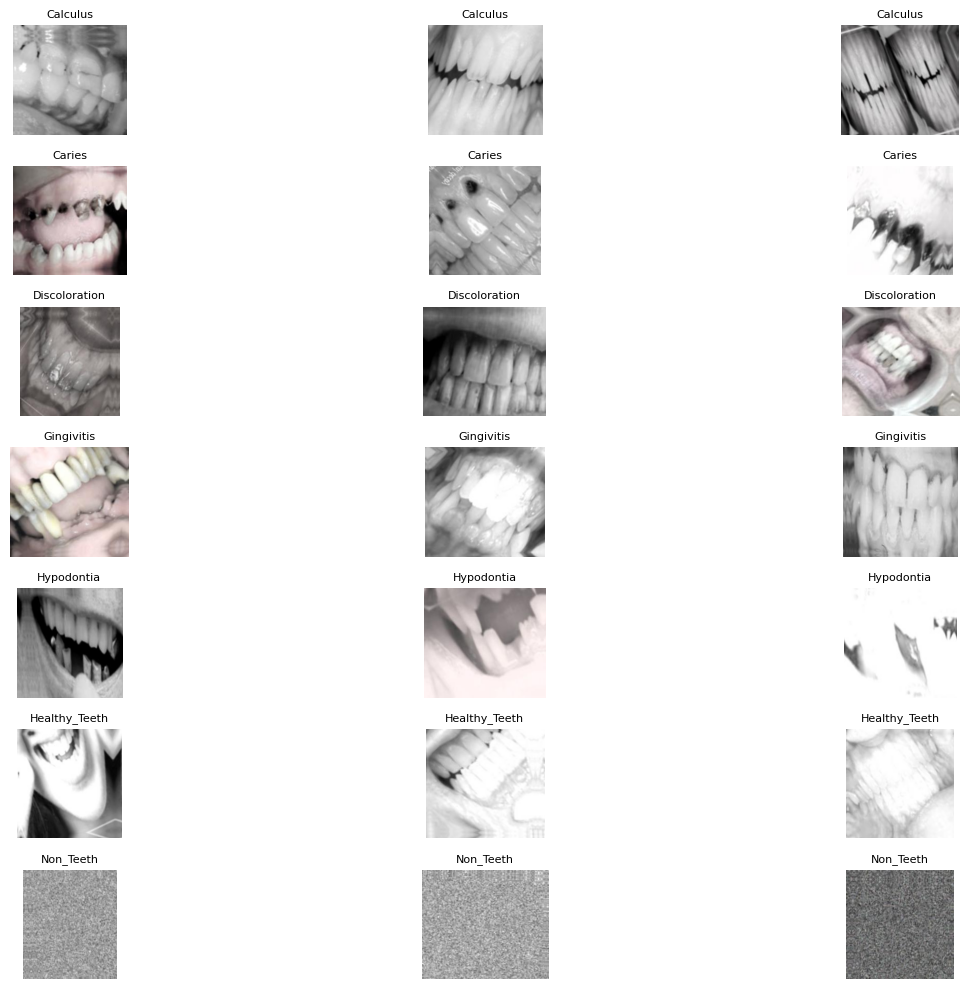

In [4]:
import matplotlib.pyplot as plt
import random

# Number of augmented images to display per class
num_display_aug = 3

print("🖼️ Menampilkan contoh gambar setelah Augmentasi:")

plt.figure(figsize=(15, 10))
for i, c in enumerate(CLASSES):
    class_dir = os.path.join(CLEAN_DATASET_DIR, c)

    # Filter for augmented images, excluding original images if possible by naming convention
    # Assuming augmented images have 'aug_cv_hybrid_' prefix from the previous cell.
    augmented_images = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.startswith('aug_cv_hybrid_')]

    if len(augmented_images) > 0:
        # Select a few random augmented images to display
        selected_images = random.sample(augmented_images, min(len(augmented_images), num_display_aug))

        for j, img_path in enumerate(selected_images):
            ax = plt.subplot(len(CLASSES), num_display_aug, i * num_display_aug + j + 1)
            img = plt.imread(img_path)
            plt.imshow(img)
            plt.title(f"{c}", fontsize=8)
            plt.axis("off")
    else:
        # If no augmented images, display a placeholder or original image if available
        # For now, just print a message
        print(f"  Tidak ada gambar augmentasi untuk kelas {c} untuk ditampilkan.")

plt.tight_layout()
plt.show()


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_DATASET_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_DATASET_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

train_loader = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_loader = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
class_names_final = train_ds.class_names

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(len(class_names_final), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_dental_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

print("\n🚀 Memulai Training CheckGigi AI...")
history = model.fit(train_loader, validation_data=val_loader, epochs=30, callbacks=callbacks)

Found 3500 files belonging to 7 classes.
Using 2800 files for training.
Found 3500 files belonging to 7 classes.
Using 700 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Memulai Training CheckGigi AI...
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2180 - loss: 1.9382
Epoch 1: val_loss improved from None to 1.46418, saving model to best_dental_model.h5



Epoch 1: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.3050 - loss: 1.7827 - val_accuracy: 0.4614 - val_loss: 1.4642
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4194 - loss: 1.5220
Epoch 2: val_loss improved from 1.46418 to 1.27005, saving model to best_dental_model.h5



Epoch 2: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.4364 - loss: 1.4605 - val_accuracy: 0.5171 - val_loss: 1.2700
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4777 - loss: 1.3273
Epoch 3: val_loss improved from 1.27005 to 1.16640, saving model to best_dental_model.h5



Epoch 3: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.4832 - loss: 1.3071 - val_accuracy: 0.5671 - val_loss: 1.1664
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5255 - loss: 1.2375
Epoch 4: val_loss improved from 1.16640 to 1.09747, saving model to best_dental_model.h5



Epoch 4: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.5404 - loss: 1.2095 - val_accuracy: 0.5771 - val_loss: 1.0975
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5640 - loss: 1.1734
Epoch 5: val_loss improved from 1.09747 to 1.04823, saving model to best_dental_model.h5


...


Epoch 26: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.7196 - loss: 0.7617 - val_accuracy: 0.7114 - val_loss: 0.7603
Epoch 27/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7213 - loss: 0.7696
Epoch 27: val_loss improved from 0.76028 to 0.75492, saving model to best_dental_model.h5



Epoch 27: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.7250 - loss: 0.7591 - val_accuracy: 0.7129 - val_loss: 0.7549
Epoch 28/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7225 - loss: 0.7536
Epoch 28: val_loss improved from 0.75492 to 0.75153, saving model to best_dental_model.h5



Epoch 28: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.7214 - loss: 0.7501 - val_accuracy: 0.7171 - val_loss: 0.7515
Epoch 29/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7383 - loss: 0.7436
Epoch 29: val_loss improved from 0.75153 to 0.74735, saving model to best_dental_model.h5



Epoch 29: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7307 - loss: 0.7433 - val_accuracy: 0.7157 - val_loss: 0.7474
Epoch 30/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7204 - loss: 0.7433
Epoch 30: val_loss improved from 0.74735 to 0.74406, saving model to best_dental_model.h5



Epoch 30: finished saving model to best_dental_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.7271 - loss: 0.7321 - val_accuracy: 0.7171 - val_loss: 0.7441
Restoring model weights from the end of the best epoch: 30.


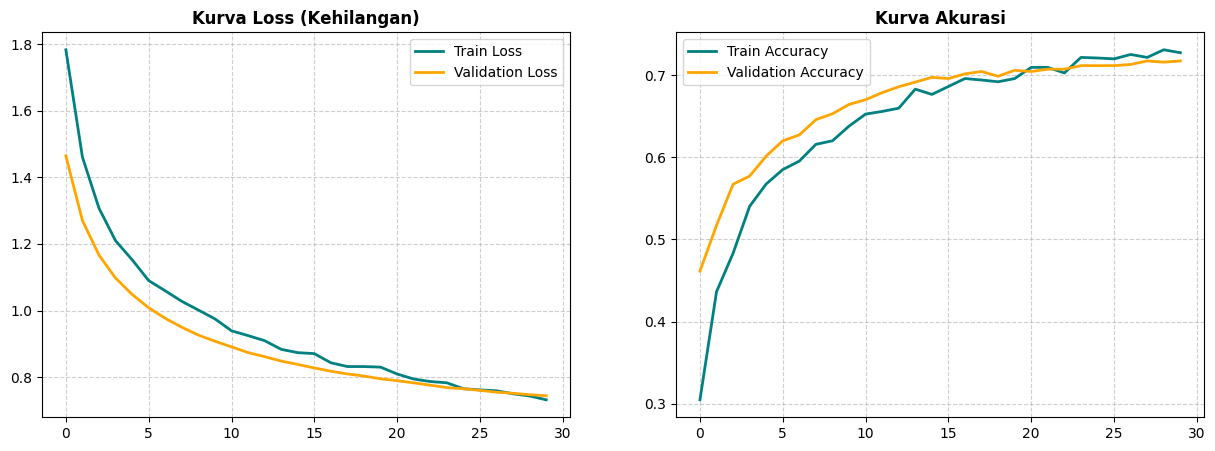


⏳ Mengumpulkan data prediksi untuk Confusion Matrix...

📊 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Calculus       0.58      0.54      0.56        83
       Caries       0.55      0.53      0.54       105
Discoloration       0.65      0.58      0.61       102
   Gingivitis       0.53      0.59      0.56       105
Healthy_Teeth       0.83      0.94      0.88        86
   Hypodontia       0.83      0.82      0.83       110
    Non_Teeth       1.00      1.00      1.00       109

     accuracy                           0.72       700
    macro avg       0.71      0.71      0.71       700
 weighted avg       0.72      0.72      0.72       700



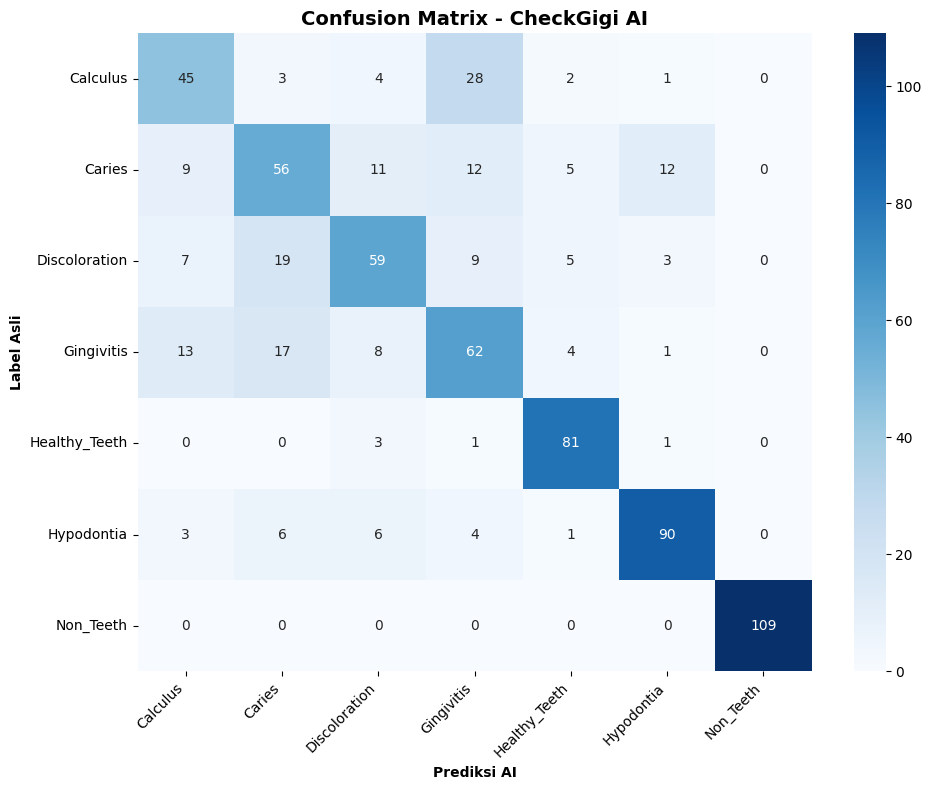

In [7]:
# 1. Plot History Training
hist = history.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(hist['loss'], label='Train Loss', color='teal', linewidth=2)
ax1.plot(hist['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('Kurva Loss (Kehilangan)', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(hist['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
ax2.plot(hist['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax2.set_title('Kurva Akurasi', fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Persiapan Confusion Matrix
print("\n⏳ Mengumpulkan data prediksi untuk Confusion Matrix...")
model.load_weights('best_dental_model.h5') # Diperbaiki: Ubah nama file menjadi 'best_dental_model.h5'

y_true = []
y_pred = []

for images, labels in val_loader:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 3. Cetak Classification Report
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names_final))

# 4. Gambar Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_final, yticklabels=class_names_final)
plt.xlabel('Prediksi AI', fontweight='bold')
plt.ylabel('Label Asli', fontweight='bold')
plt.title('Confusion Matrix - CheckGigi AI', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
print("\n🏁 Mengonversi ke TensorFlow Lite untuk Android...")
model.load_weights('best_dental_model.h5') # Load the correct best model weights
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'checkgigi_model_v1.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"📦 Selesai! Model siap didownload: {tflite_path}")
print("\n⚠️ PENTING UNTUK KODE ANDROID (Catat Index Ini):")
for i, name in enumerate(class_names_final):
    print(f"Index {i} = {name}")


🏁 Mengonversi ke TensorFlow Lite untuk Android...
Saved artifact at '/tmp/tmp4o_qz1vb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_250')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133842997558736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133842997559120: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133843000854672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000854480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000855056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000856016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000856592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000855440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133843000855248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13384300085

/tmp/ipykernel_4555/2764210464.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


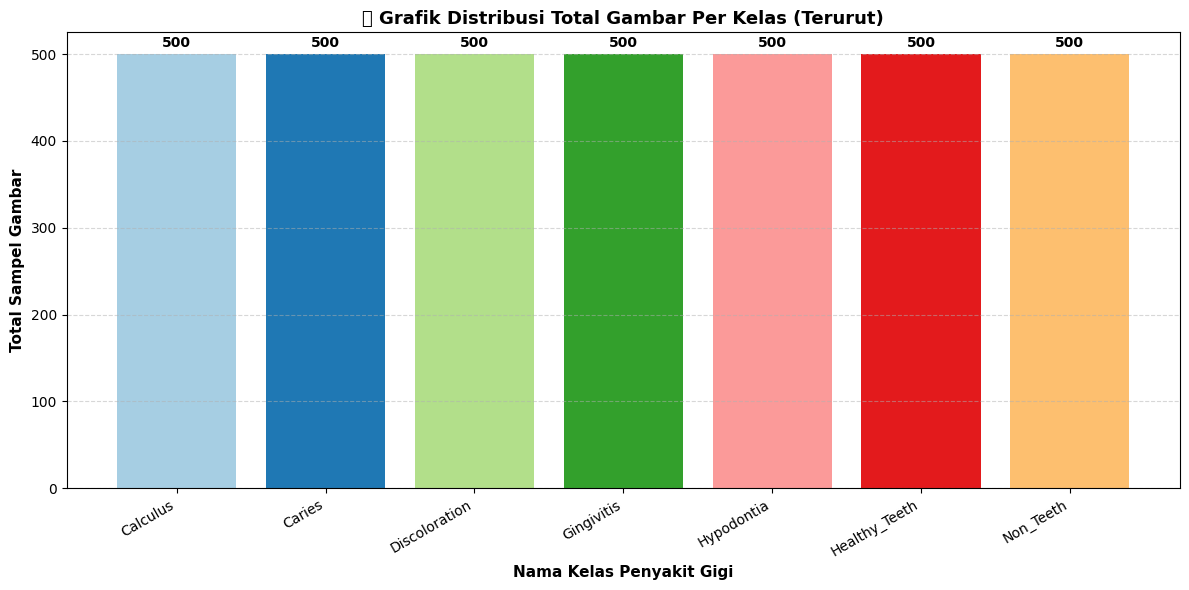

In [11]:
import os
import matplotlib.pyplot as plt

# 1. Hitung jumlah file per folder kelas secara riil
class_counts = {}
for kelas in CLASSES: # Diperbaiki: Menggunakan CLASSES yang sudah didefinisikan
    jalur_kelas = os.path.join(CLEAN_DATASET_DIR, kelas) # Diperbaiki: Menggunakan CLEAN_DATASET_DIR
    jumlah_foto = len([f for f in os.listdir(jalur_kelas) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[kelas] = jumlah_foto

# 2. Urutkan kelas berdasarkan jumlah gambar terbanyak ke tersedikit
sorted_counts = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
kelas_terurut = [item[0] for item in sorted_counts]
jumlah_terurut = [item[1] for item in sorted_counts]

# 3. Gambar Grafik Batang
plt.figure(figsize=(12, 6))
bars = plt.bar(kelas_terurut, jumlah_terurut, color=plt.cm.Paired(range(len(CLASSES)))) # Diperbaiki: Menggunakan CLASSES

plt.xlabel('Nama Kelas Penyakit Gigi', fontsize=11, fontweight='bold')
plt.ylabel('Total Sampel Gambar', fontsize=11, fontweight='bold')
plt.title('📊 Grafik Distribusi Total Gambar Per Kelas (Terurut)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambahkan label angka di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

⏳ Memuat bobot model terbaik untuk proses evaluasi final...
⏳ AI sedang menguji seluruh sampel data validasi secara lokal...

📊 CLASSIFICATION REPORT (DATA VALIDASI KONTROL):
               precision    recall  f1-score   support

     Calculus       0.58      0.54      0.56        83
       Caries       0.55      0.53      0.54       105
Discoloration       0.65      0.58      0.61       102
   Gingivitis       0.53      0.59      0.56       105
Healthy_Teeth       0.83      0.94      0.88        86
   Hypodontia       0.83      0.82      0.83       110
    Non_Teeth       1.00      1.00      1.00       109

     accuracy                           0.72       700
    macro avg       0.71      0.71      0.71       700
 weighted avg       0.72      0.72      0.72       700



/tmp/ipykernel_4555/1444802713.py:35: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


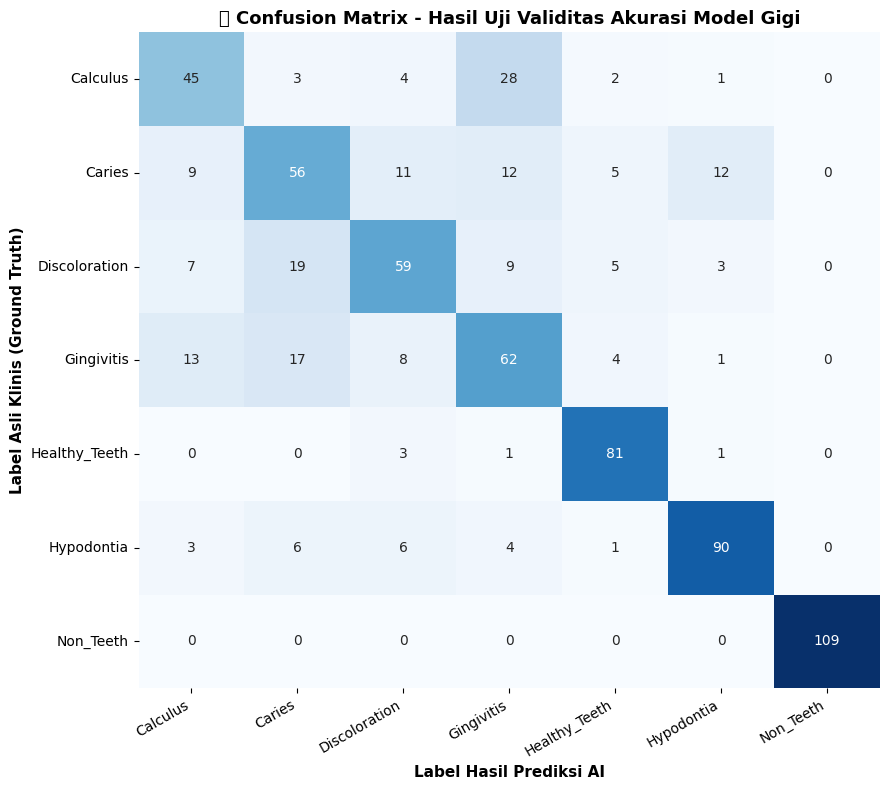

In [14]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("⏳ Memuat bobot model terbaik untuk proses evaluasi final...")
model.load_weights('best_dental_model.h5')

y_true = []
y_pred = []

print("⏳ AI sedang menguji seluruh sampel data validasi secara lokal...")
for images, labels in val_loader:
    # Lakukan prediksi array probabilitas
    preds = model.predict(images, verbose=0)
    # Ambil indeks kelas dengan probabilitas tertinggi
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

# 1. Cetak Laporan Evaluasi Utama (Precision, Recall, F1-Score)
print("\n📊 CLASSIFICATION REPORT (DATA VALIDASI KONTROL):")
print(classification_report(y_true, y_pred, target_names=class_names_final)) # Diperbaiki: Menggunakan class_names_final

# 2. Gambar Grafik Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_final, yticklabels=class_names_final, cbar=False) # Diperbaiki: Menggunakan class_names_final

plt.xlabel('Label Hasil Prediksi AI', fontsize=11, fontweight='bold')
plt.ylabel('Label Asli Klinis (Ground Truth)', fontsize=11, fontweight='bold')
plt.title('🧩 Confusion Matrix - Hasil Uji Validitas Akurasi Model Gigi', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()